# Prediction analysis

This is to analyse the predicted ages.

In [14]:
import os
# Temporary workaround: allow duplicate OpenMP runtimes so the kernel can start.
# NOTE: This is unsafe and can mask real issues. See safer fixes below.
os.environ["KMP_DUPLICATE_LIB_OK"] = "True"
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch

# Save directory for biological metrics plots
save_dir = 'biological_metrics_MCIandAD'
os.makedirs(save_dir, exist_ok=True)

# Load the predicted ages
results_df = pd.read_csv('..\\..\\Compare_Model\\QSM+MD+Thickness_subject_level_mean_raw_and_corrected_pred_on_age.csv')

# # Add the MCI and AD subjects or not
MCIandAD_df = pd.read_csv('..\\..\\Compare_Model\\QSM+MD+Thickness_subject_level_mean_raw_and_corrected_pred_on_age_MCIandAD.csv')
# Combine the two dataframes
results_df = pd.concat([results_df, MCIandAD_df], ignore_index=True)

# Load metadata
METADATA_PATH = "../../../AD_DECODE_data6_with_cBAGs_and_PCA.xlsx" # "../../../AD_DECODE_data3.xlsx"
PCs_PATH = "../../../metadata_with_PCs_imputed.xlsx"
metadata_df = pd.read_excel(METADATA_PATH)
PCs_df = pd.read_excel(PCs_PATH)

# Merge results with metadata by 'subject_id' in result_df and 'MRI_Exam' in metadata_df
# subject_id is like 02110
# MRI_Exam is like 2110
# Convert 'MRI_Exam' to match 'subject_id' format
metadata_df['subject_id'] = metadata_df['MRI_Exam'].apply(lambda x: f"{int(x):05d}" if pd.notnull(x) else np.nan)
PCs_df['subject_id'] = PCs_df['MRI_Exam'].apply(lambda x: f"{int(x):05d}" if pd.notnull(x) else np.nan)
# Ensure both subject_id columns are strings for merging
results_df['subject_id'] = results_df['subject_id'].apply(lambda x: f"{int(x):05d}")
# Merge the dataframes
PCs_cols = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'PC12', 'PC13', 'PC14', 'PC15',
            'PC16', 'PC17', 'PC18', 'PC19', 'PC20', 'PC21', 'PC22', 'PC23', 'PC24', 'PC25', 'PC26', 'PC27', 'PC28', 'PC29', 'PC30',
            'blood_missing']
merged_df = pd.merge(results_df, metadata_df, on='subject_id', how='left')
merged_df = pd.merge(merged_df, PCs_df[['subject_id'] + PCs_cols], on='subject_id', how='left')
merged_df = merged_df.dropna(subset=['bag_raw', 'bag_corr'])  # Drop rows with NaN in 'bag_raw' or 'bag_corr'


In [15]:
merged_df['APOE4'] = merged_df['genotype'].apply(lambda x: 1 if x in ['APOE34', 'APOE44'] else 0)

In [16]:
# Save the merged dataframe for future use
merged_df.to_csv(os.path.join(save_dir, 'merged_results_with_metadata.csv'), index=False)

## Subjects Stats

In [17]:
# Print tota; number of subjects after merging
print(f"Total number of subjects after merging: {len(merged_df)}")
# Print number of genotype 1 and 0 subjects
print(f"Number of APOE4 genotype 1 subjects: {merged_df['APOE4'].sum()}")
print(f"Number of APOE4 genotype 0 subjects: {len(merged_df) - merged_df['APOE4'].sum()}")  
# Print number of males and females in genotype 1 and 0
print("Genotype 1 (APOE4 carriers):")
print(merged_df[merged_df['APOE4'] == 1]['sex'].value_counts())
print("Genotype 0 (non-APOE4 carriers):")
print(merged_df[merged_df['APOE4'] == 0]['sex'].value_counts())

Total number of subjects after merging: 64
Number of APOE4 genotype 1 subjects: 31
Number of APOE4 genotype 0 subjects: 33
Genotype 1 (APOE4 carriers):
sex
F    18
M    13
Name: count, dtype: int64
Genotype 0 (non-APOE4 carriers):
sex
F    19
M    14
Name: count, dtype: int64


In [18]:
# Print number of subjects with each genotype
print("Genotype counts:")   
print(merged_df['genotype'].value_counts())

Genotype counts:
genotype
APOE33    27
APOE34    24
APOE44     7
APOE23     6
Name: count, dtype: int64


In [19]:
# Print number of subjects below median age in genotype 1 and 0
median_age = merged_df['age'].median()
max_age = merged_df['age'].max()
min_age = merged_df['age'].min()
print(f"Median age: {median_age}, Max age: {max_age}, Min age: {min_age}")
print("Genotype 1 (APOE4 carriers):")
print(f"Number of subjects below median age ({median_age}): {len(merged_df[(merged_df['APOE4'] == 1) & (merged_df['age'] < median_age)])}")
print("Genotype 0 (non-APOE4 carriers):")
print(f"Number of subjects below median age ({median_age}): {len(merged_df[(merged_df['APOE4'] == 0) & (merged_df['age'] < median_age)])}")

Median age: 52.0, Max age: 82.0, Min age: 20.21
Genotype 1 (APOE4 carriers):
Number of subjects below median age (52.0): 18
Genotype 0 (non-APOE4 carriers):
Number of subjects below median age (52.0): 13


In [20]:
# Print number of subjects with each ethnicity in genotype 1 and 0
print("Ethnicity counts in Genotype 1 (APOE4 carriers):")
print(merged_df[merged_df['APOE4'] == 1]['ethnicity'].value_counts())
print("Ethnicity counts in Genotype 0 (non-APOE4 carriers):")
print(merged_df[merged_df['APOE4'] == 0]['ethnicity'].value_counts())

Ethnicity counts in Genotype 1 (APOE4 carriers):
ethnicity
caucasian    26
aa            4
latino        1
Name: count, dtype: int64
Ethnicity counts in Genotype 0 (non-APOE4 carriers):
ethnicity
caucasian    27
aa            2
asian         2
hispanic      1
latino        1
Name: count, dtype: int64


In [21]:
# Print number of subjects with each risk in genotype 1 and 0
print("Risk counts in Genotype 1 (APOE4 carriers):")
print(merged_df[merged_df['APOE4'] == 1]['Risk'].value_counts())
print("Risk counts in Genotype 0 (non-APOE4 carriers):")
print(merged_df[merged_df['APOE4'] == 0]['Risk'].value_counts())

Risk counts in Genotype 1 (APOE4 carriers):
Risk
Familial    27
MCI          1
Name: count, dtype: int64
Risk counts in Genotype 0 (non-APOE4 carriers):
Risk
Familial    15
MCI          3
AD           1
Name: count, dtype: int64


## Violin Plots

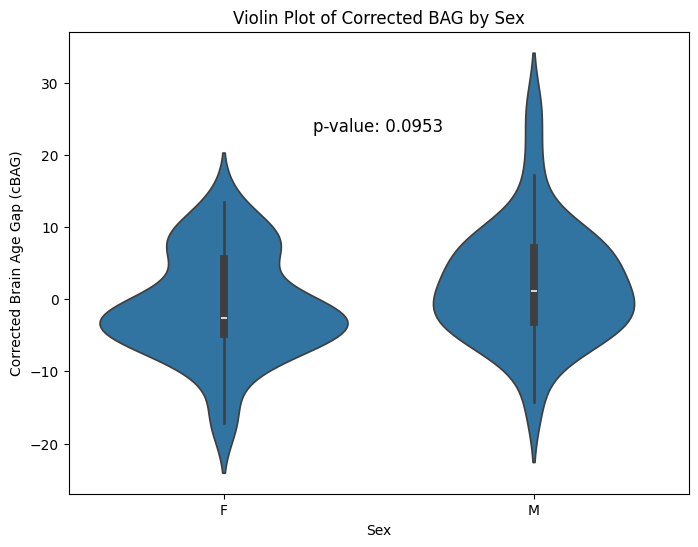

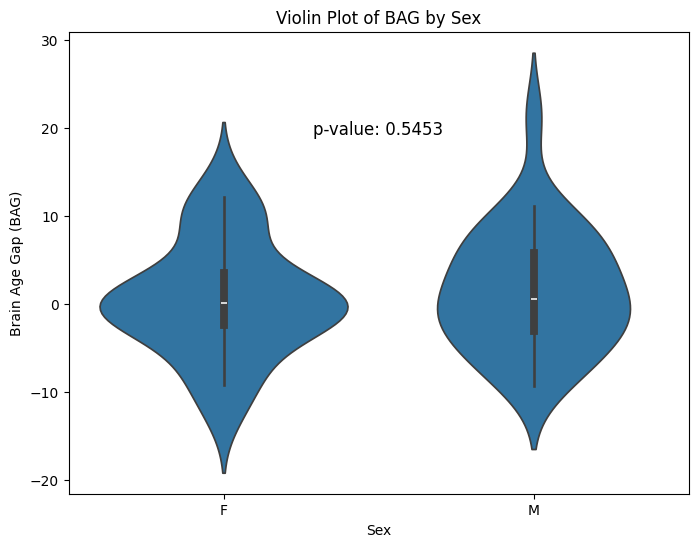

In [22]:
# Plot the violin plots of BAG / cBAG versus sex
import seaborn as sns
# Calculate the p-values of sex using t-tests
from scipy.stats import ttest_ind
p_value_corr = ttest_ind(merged_df[merged_df['sex'] == 'M']['bag_corr'],
                          merged_df[merged_df['sex'] == 'F']['bag_corr']).pvalue
p_value_raw = ttest_ind(merged_df[merged_df['sex'] == 'M']['bag_raw'],
                        merged_df[merged_df['sex'] == 'F']['bag_raw']).pvalue

plt.figure(figsize=(8, 6))
sns.violinplot(x='sex', y='bag_corr', data=merged_df)
plt.title('Violin Plot of Corrected BAG by Sex')
plt.xlabel('Sex')
plt.ylabel('Corrected Brain Age Gap (cBAG)')
plt.text(0.5, max(merged_df['bag_corr']) * 0.9, f'p-value: {p_value_corr:.4f}', 
         horizontalalignment='center', fontsize=12)
plt.savefig(os.path.join(save_dir, 'violin_plot_corrected_bag_by_sex.png'))
plt.show()

plt.figure(figsize=(8, 6))
sns.violinplot(x='sex', y='bag_raw', data=merged_df)
plt.title('Violin Plot of BAG by Sex')
plt.xlabel('Sex')
plt.ylabel('Brain Age Gap (BAG)')
plt.text(0.5, max(merged_df['bag_raw']) * 0.9, f'p-value: {p_value_raw:.4f}', 
         horizontalalignment='center', fontsize=12)
plt.savefig(os.path.join(save_dir, 'violin_plot_bag_by_sex.png'))
plt.show()

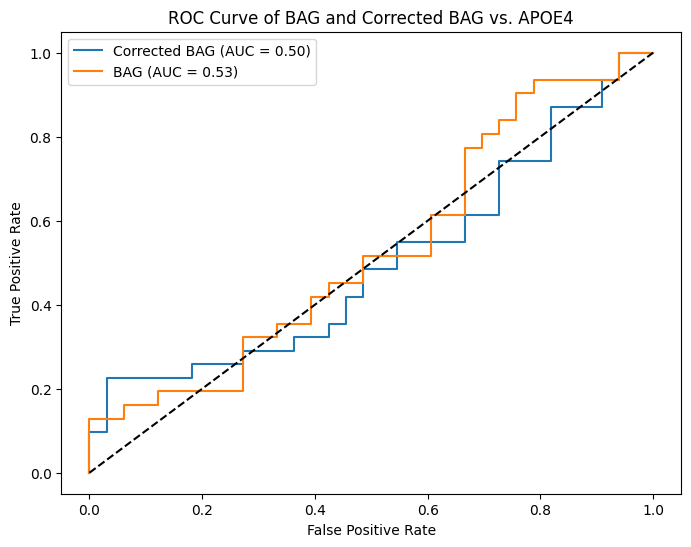

In [23]:
# Plot auc curve of BAG / cBAG versus APOE4
from sklearn.metrics import roc_auc_score, roc_curve
fpr_corr, tpr_corr, _ = roc_curve(merged_df['APOE4'], merged_df['bag_corr'])
fpr_raw, tpr_raw, _ = roc_curve(merged_df['APOE4'], merged_df['bag_raw'])
auc_corr = roc_auc_score(merged_df['APOE4'], merged_df['bag_corr'])
auc_raw = roc_auc_score(merged_df['APOE4'], merged_df['bag_raw'])

plt.figure(figsize=(8, 6))
plt.plot(fpr_corr, tpr_corr, label=f'Corrected BAG (AUC = {auc_corr:.2f})')
plt.plot(fpr_raw, tpr_raw, label=f'BAG (AUC = {auc_raw:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve of BAG and Corrected BAG vs. APOE4')
plt.legend()
plt.savefig(os.path.join(save_dir, 'roc_curve_bag_vs_aPOE4.png'))
plt.show()

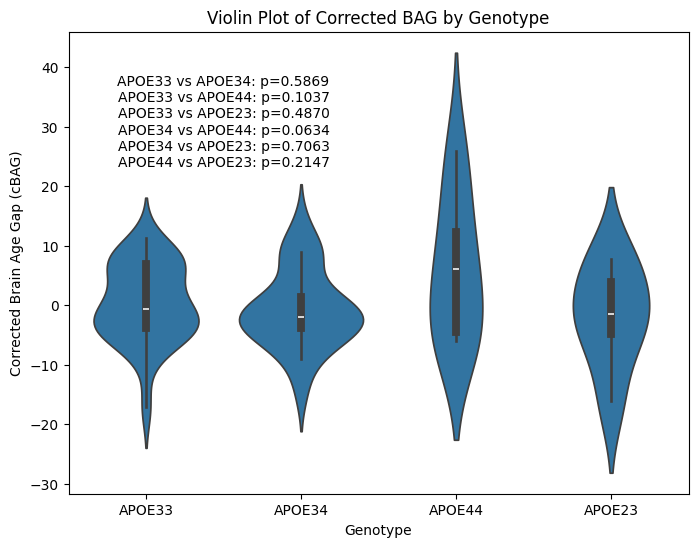

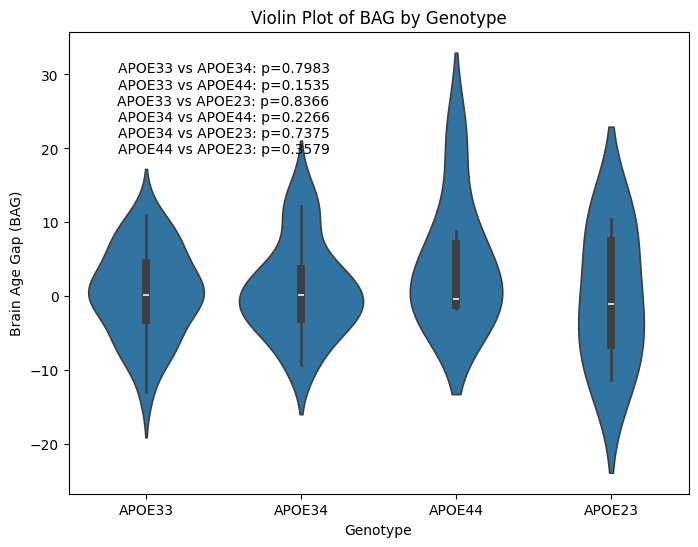

In [24]:
# Plot the violin plots of BAG / cBAG versus genotype
import seaborn as sns
# Calculate the p-values of genotype
from scipy.stats import ttest_ind

# Pairwise t-tests between genotypes
genotypes = merged_df['genotype'].unique()
p_values_corr = {}
p_values_raw = {}
for i in range(len(genotypes)):
    for j in range(i + 1, len(genotypes)):
        g1 = genotypes[i]
        g2 = genotypes[j]
        p_val_corr = ttest_ind(merged_df[merged_df['genotype'] == g1]['bag_corr'],
                               merged_df[merged_df['genotype'] == g2]['bag_corr']).pvalue
        p_val_raw = ttest_ind(merged_df[merged_df['genotype'] == g1]['bag_raw'],
                              merged_df[merged_df['genotype'] == g2]['bag_raw']).pvalue
        p_values_corr[(g1, g2)] = p_val_corr
        p_values_raw[(g1, g2)] = p_val_raw

# Create violin plots and add p-values to the plots
plt.figure(figsize=(8, 6))
sns.violinplot(x='genotype', y='bag_corr', data=merged_df)
plt.title('Violin Plot of Corrected BAG by Genotype')
plt.xlabel('Genotype')
plt.ylabel('Corrected Brain Age Gap (cBAG)')
plt.text(0.5, max(merged_df['bag_corr']) * 0.9, 
         '\n'.join([f'{k[0]} vs {k[1]}: p={v:.4f}' for k, v in p_values_corr.items()]),
         horizontalalignment='center', fontsize=10)
plt.savefig(os.path.join(save_dir, 'violin_plot_corrected_bag_by_genotype.png'))
plt.show()

plt.figure(figsize=(8, 6))
sns.violinplot(x='genotype', y='bag_raw', data=merged_df)
plt.title('Violin Plot of BAG by Genotype')
plt.xlabel('Genotype')
plt.ylabel('Brain Age Gap (BAG)')
plt.text(0.5, max(merged_df['bag_raw']) * 0.9, 
         '\n'.join([f'{k[0]} vs {k[1]}: p={v:.4f}' for k, v in p_values_raw.items()]),
         horizontalalignment='center', fontsize=10)
plt.savefig(os.path.join(save_dir, 'violin_plot_bag_by_genotype.png'))
plt.show()

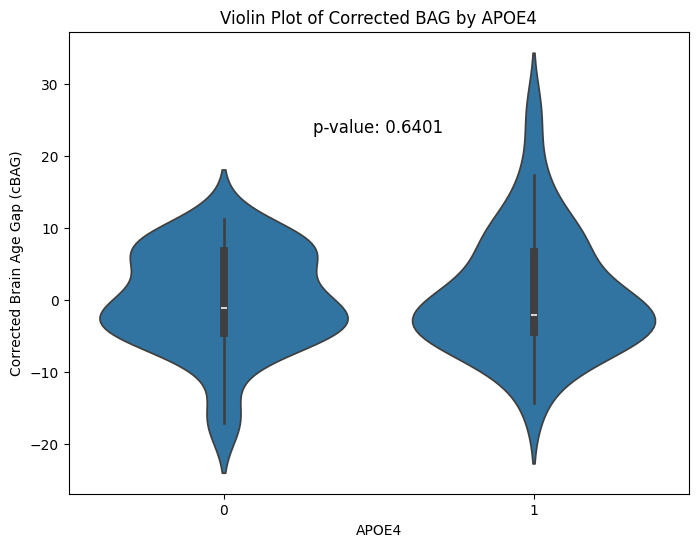

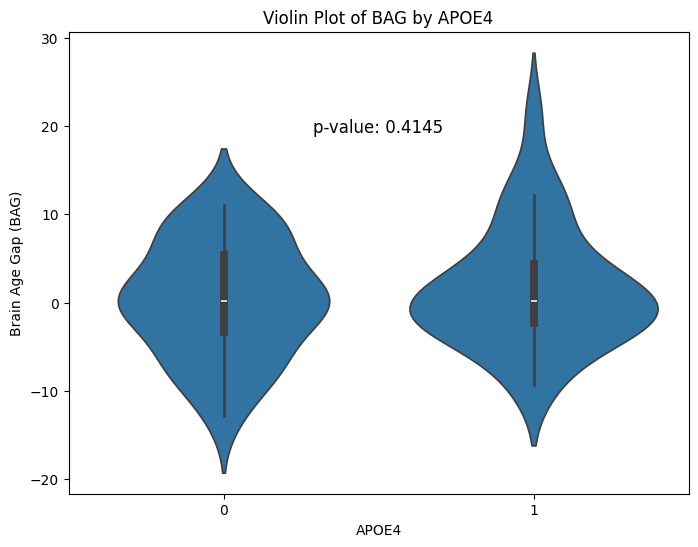

In [25]:
# Plot the violin plots of BAG / cBAG versus APOE4
import seaborn as sns
# Calculate the p-values of APOE4
from scipy.stats import ttest_ind
p_value_corr = ttest_ind(merged_df[merged_df['APOE4'] == 1]['bag_corr'],
                          merged_df[merged_df['APOE4'] == 0]['bag_corr']).pvalue
p_value_raw = ttest_ind(merged_df[merged_df['APOE4'] == 1]['bag_raw'],
                        merged_df[merged_df['APOE4'] == 0]['bag_raw']).pvalue
plt.figure(figsize=(8, 6))
sns.violinplot(x='APOE4', y='bag_corr', data=merged_df)
plt.title('Violin Plot of Corrected BAG by APOE4')
plt.xlabel('APOE4')
plt.ylabel('Corrected Brain Age Gap (cBAG)')
plt.text(0.5, max(merged_df['bag_corr']) * 0.9, f'p-value: {p_value_corr:.4f}', 
         horizontalalignment='center', fontsize=12)
plt.savefig(os.path.join(save_dir, 'violin_plot_corrected_bag_by_APOE4.png'))
plt.show()

plt.figure(figsize=(8, 6))
sns.violinplot(x='APOE4', y='bag_raw', data=merged_df)
plt.title('Violin Plot of BAG by APOE4')
plt.xlabel('APOE4')
plt.ylabel('Brain Age Gap (BAG)')
plt.text(0.5, max(merged_df['bag_raw']) * 0.9, f'p-value: {p_value_raw:.4f}', 
         horizontalalignment='center', fontsize=12)
plt.savefig(os.path.join(save_dir, 'violin_plot_bag_by_APOE4.png'))
plt.show()

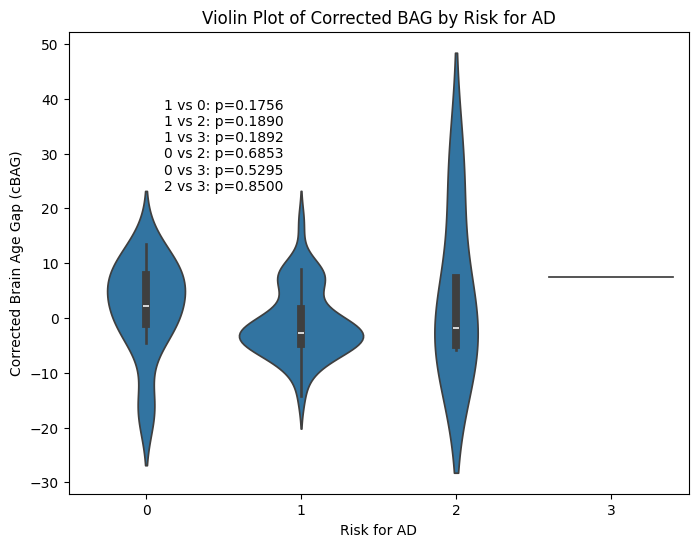

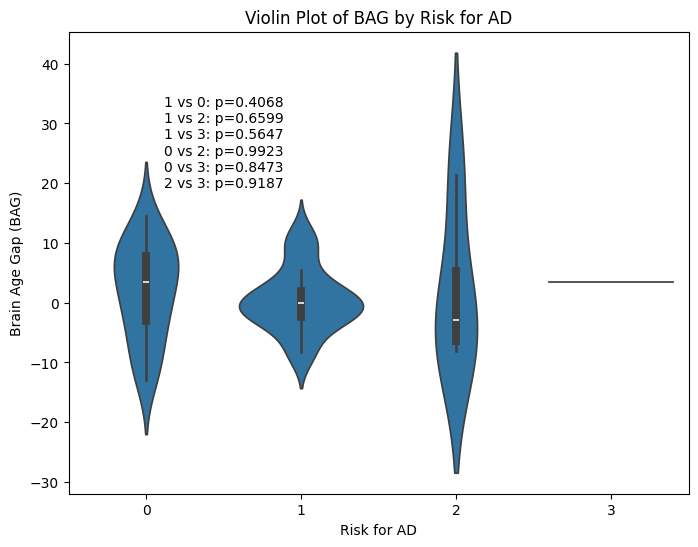

In [26]:
# Pairwise t-tests between risk for AD groups
risk_groups = merged_df['risk_for_ad'].unique()
p_values_corr = {}
p_values_raw = {}
for i in range(len(risk_groups)):
    for j in range(i + 1, len(risk_groups)):
        g1 = risk_groups[i]
        g2 = risk_groups[j]
        p_val_corr = ttest_ind(merged_df[merged_df['risk_for_ad'] == g1]['bag_corr'],
                               merged_df[merged_df['risk_for_ad'] == g2]['bag_corr']).pvalue
        p_val_raw = ttest_ind(merged_df[merged_df['risk_for_ad'] == g1]['bag_raw'],
                              merged_df[merged_df['risk_for_ad'] == g2]['bag_raw']).pvalue
        p_values_corr[(g1, g2)] = p_val_corr
        p_values_raw[(g1, g2)] = p_val_raw

# Plot the violin plots of BAG / cBAG versus risk factors
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.violinplot(x='risk_for_ad', y='bag_corr', data=merged_df)
plt.title('Violin Plot of Corrected BAG by Risk for AD')
plt.xlabel('Risk for AD')
plt.ylabel('Corrected Brain Age Gap (cBAG)')
plt.text(0.5, max(merged_df['bag_corr']) * 0.9, 
         '\n'.join([f'{k[0]} vs {k[1]}: p={v:.4f}' for k, v in p_values_corr.items()]),
         horizontalalignment='center', fontsize=10)
plt.savefig(os.path.join(save_dir, 'violin_plot_corrected_bag_by_risk_for_ad.png'))
plt.show()

plt.figure(figsize=(8, 6))
sns.violinplot(x='risk_for_ad', y='bag_raw', data=merged_df)
plt.title('Violin Plot of BAG by Risk for AD')
plt.xlabel('Risk for AD')
plt.ylabel('Brain Age Gap (BAG)')
plt.text(0.5, max(merged_df['bag_raw']) * 0.9, 
         '\n'.join([f'{k[0]} vs {k[1]}: p={v:.4f}' for k, v in p_values_raw.items()]),
         horizontalalignment='center', fontsize=10)
plt.savefig(os.path.join(save_dir, 'violin_plot_bag_by_risk_for_ad.png'))
plt.show()

## cBAG vs. cognitive score


### cBAG vs. single original cognitive score

In [17]:
# Plot the cBAG vs column from 'MOCA_TOTAL' to 'Delayed_paraphrase'
import seaborn as sns

cognitive_start = merged_df.columns.get_loc('MOCA_TOTAL')
cognitive_end = merged_df.columns.get_loc('Delayed_paraphrase') + 1
cognitive_columns = merged_df.columns[cognitive_start:cognitive_end]

# Convert all cognitive columns to numeric, coercing errors to NaN
for col in cognitive_columns:
    merged_df[col] = pd.to_numeric(merged_df[col], errors='coerce')

R2 = []
p_values = []

for column in cognitive_columns:
    # Drop rows with NaN in either column for this analysis
    x = merged_df[column]
    y = merged_df['bag_corr']
    mask = x.notna() & y.notna()
    x = x[mask]
    y = y[mask]
    # Ignore if x or y has identical values (no variance)
    if x.nunique() <= 1 or y.nunique() <= 1:
        R2.append(np.nan)
        p_values.append(np.nan)
        continue
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, alpha=0.5)
    # Add a regression line with R2 and p-value
    sns.regplot(x=x, y=y, scatter=False, color='red', line_kws={'label': 'Regression Line'})
    if len(x) > 1 and len(y) > 1:
        r_squared = np.corrcoef(x, y)[0, 1] ** 2
        from scipy.stats import linregress
        slope, intercept, r_value, p_value, std_err = linregress(x, y)
    else:
        r_squared = np.nan
        p_value = np.nan
    R2.append(r_squared)
    p_values.append(p_value)
    plt.title(f'cBAG vs {column}')
    plt.legend(title=f'R² = {r_squared:.2f}, p = {p_value:.3f}')
    plt.ylabel('cBAG')
    plt.xlabel(column)
    plt.grid()
    plt.savefig(f'{save_dir}/cBAG_vs_{column}.png')
    plt.close()

# Print the top 10 cognitive columns with the highest R2 values
cognitive_r2_df = pd.DataFrame({'cognitive_column': cognitive_columns, 'R2': R2, 'p_value': p_values})
cognitive_r2_df = cognitive_r2_df.sort_values(by='R2', ascending=False)
# Save the R2 and p-values to a CSV file
cognitive_r2_df.to_csv(f'{save_dir}/cBAG_vs_cognition_r2_p_values.csv', index=False)
# Print the top 10 cognitive columns with highest R² values
top_10_cognitive = cognitive_r2_df.head(10)
print("Top 10 cognitive columns with highest R² values:")
print(top_10_cognitive)
# Print the top 10 cognitive columns with lowest p-values
top_10_cognitive_p = cognitive_r2_df.sort_values(by='p_value').head(10)
print("\nTop 10 cognitive columns with lowest p-values:")
print(top_10_cognitive_p)


C:\Users\22679\AppData\Local\Temp\ipykernel_29312\1005551410.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=f'R² = {r_squared:.2f}, p = {p_value:.3f}')


Top 10 cognitive columns with highest R² values:
         cognitive_column        R2   p_value
2       Delay_BensonTotal  0.075646  0.029139
6   Composite_Nameability  0.042546  0.104826
30     Delayed_paraphrase  0.034173  0.146941
15         fwd_max_length  0.028031  0.189668
14      fwd_total_correct  0.027074  0.197515
17      bckwds_max_length  0.024541  0.220164
0              MOCA_TOTAL  0.018258  0.291029
16   bckwds_total_correct  0.016631  0.313779
23         letter_fluency  0.015617  0.329129
4     Composite_Intensity  0.014128  0.353497

Top 10 cognitive columns with lowest p-values:
         cognitive_column        R2   p_value
2       Delay_BensonTotal  0.075646  0.029139
6   Composite_Nameability  0.042546  0.104826
30     Delayed_paraphrase  0.034173  0.146941
15         fwd_max_length  0.028031  0.189668
14      fwd_total_correct  0.027074  0.197515
17      bckwds_max_length  0.024541  0.220164
0              MOCA_TOTAL  0.018258  0.291029
16   bckwds_total_correct  0.

In [18]:
# Compute FDR correction for p-values
from statsmodels.stats.multitest import multipletests
_, corrected_p_values, _, _ = multipletests(p_values, method='fdr_bh')
# Save the FDR corrected p-value results to a CSV file
# Sort from lowest to highest p-value
cognitive_r2_df['corrected_p_value'] = corrected_p_values
cognitive_r2_df = cognitive_r2_df.sort_values(by='corrected_p_value')
cognitive_r2_df.to_csv(f'{save_dir}/cBAG_vs_cognition_r2_FDR_corrected_p_values.csv', index=False)


### cBAG vs. z-scored cognitive score composite

In [19]:
# Plot the cBAG vs column from 'Memory_Composite' to 'Global_Cognition_Composite'
import seaborn as sns

z_cognitive_start = merged_df.columns.get_loc('Memory_Composite')
z_cognitive_end = merged_df.columns.get_loc('Global_Cognition_Composite') + 1
z_cognitive_columns = merged_df.columns[z_cognitive_start:z_cognitive_end]

R2 = []
p_values = []

for column in z_cognitive_columns:
    # Drop rows with NaN in either column for this analysis
    x = merged_df[column]
    y = merged_df['bag_corr']
    mask = x.notna() & y.notna()
    x = x[mask]
    y = y[mask]
    # Ignore if x or y has identical values (no variance)
    if x.nunique() <= 1 or y.nunique() <= 1:
        R2.append(np.nan)
        p_values.append(np.nan)
        continue
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, alpha=0.5)
    # Add a regression line with R2 and p-value
    sns.regplot(x=x, y=y, scatter=False, color='red', line_kws={'label': 'Regression Line'})
    if len(x) > 1 and len(y) > 1:
        r_squared = np.corrcoef(x, y)[0, 1] ** 2
        from scipy.stats import linregress
        slope, intercept, r_value, p_value, std_err = linregress(x, y)
    else:
        r_squared = np.nan
        p_value = np.nan
    R2.append(r_squared)
    p_values.append(p_value)
    plt.title(f'cBAG vs {column}')
    plt.legend(title=f'R² = {r_squared:.2f}, p = {p_value:.3f}')
    plt.ylabel('cBAG')
    plt.xlabel(column)
    plt.grid()
    plt.savefig(f'{save_dir}/cBAG_vs_{column}.png')
    plt.close()

# Print the top 10 cognitive columns with the highest R2 values
cognitive_r2_df = pd.DataFrame({'z_cognitive_composite_column': z_cognitive_columns, 'R2': R2, 'p_value': p_values})
cognitive_r2_df = cognitive_r2_df.sort_values(by='R2', ascending=False)
# Save the R2 and p-values to a CSV file
cognitive_r2_df.to_csv(f'{save_dir}/cBAG_vs_z_cognition_composite_r2_p_values.csv', index=False)
# Print the z-scored cognitive composite columns
print("Top z-scored cognitive composite columns with highest R² values:")
print(cognitive_r2_df.head())
# Print the z-scored cognitive composite columns with lowest p-values
top_cognitive_p = cognitive_r2_df.sort_values(by='p_value').head(10)
print("\nTop z-scored cognitive composite columns with lowest p-values:")
print(top_cognitive_p)


C:\Users\22679\AppData\Local\Temp\ipykernel_29312\1024622173.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=f'R² = {r_squared:.2f}, p = {p_value:.3f}')


Top z-scored cognitive composite columns with highest R² values:
   z_cognitive_composite_column        R2   p_value
4        Visuospatial_Composite  0.048022  0.084422
2    Processing_Speed_Composite  0.022040  0.245553
3            Language_Composite  0.013640  0.361995
0              Memory_Composite  0.006066  0.544017
1  Executive_Function_Composite  0.003407  0.649537

Top z-scored cognitive composite columns with lowest p-values:
   z_cognitive_composite_column        R2   p_value
4        Visuospatial_Composite  0.048022  0.084422
2    Processing_Speed_Composite  0.022040  0.245553
3            Language_Composite  0.013640  0.361995
0              Memory_Composite  0.006066  0.544017
1  Executive_Function_Composite  0.003407  0.649537
5    Global_Cognition_Composite  0.000878  0.817720


In [20]:
# Plot the cBAG vs column from 'Memory_Composite' to 'Global_Cognition_Composite' and sex, age, and APOE4 as covariates
import seaborn as sns

covariate_columns = ['sex_numeric', 'age', 'APOE4']
covariates = merged_df[covariate_columns]

R2 = []
p_values = []

for column in z_cognitive_columns:
    # Drop rows with NaN in either column for this analysis
    x = merged_df[column]
    y = merged_df['bag_corr']
    mask = x.notna() & y.notna() & covariates.notna().all(axis=1)
    x = x[mask]
    y = y[mask]
    covariates_subset = covariates[mask]
    x = x - covariates_subset.dot(np.linalg.lstsq(covariates_subset, x, rcond=None)[0])
    y = y - covariates_subset.dot(np.linalg.lstsq(covariates_subset, y, rcond=None)[0])
    
    # Ignore if x or y has identical values (no variance)
    if x.nunique() <= 1 or y.nunique() <= 1:
        R2.append(np.nan)
        p_values.append(np.nan)
        continue
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, alpha=0.5)
    # Add a regression line with R2 and p-value
    sns.regplot(x=x, y=y, scatter=False, color='red', line_kws={'label': 'Regression Line'})
    if len(x) > 1 and len(y) > 1:
        r_squared = np.corrcoef(x, y)[0, 1] ** 2
        from scipy.stats import linregress
        slope, intercept, r_value, p_value, std_err = linregress(x, y)
    else:
        r_squared = np.nan
        p_value = np.nan
    R2.append(r_squared)
    p_values.append(p_value)
    plt.title(f'cBAG vs adjusted {column}')
    plt.legend(title=f'R² = {r_squared:.2f}, p = {p_value:.3f}')
    plt.ylabel('cBAG')
    plt.xlabel(column)
    plt.grid()
    plt.savefig(f'{save_dir}/cBAG_vs_adjusted_{column}.png')
    plt.close()

# Print the top 10 cognitive columns with the highest R2 values
cognitive_r2_df = pd.DataFrame({'z_cognitive_composite_column': z_cognitive_columns, 'R2': R2, 'p_value': p_values})
cognitive_r2_df = cognitive_r2_df.sort_values(by='R2', ascending=False)
# Save the R2 and p-values to a CSV file
cognitive_r2_df.to_csv(f'{save_dir}/cBAG_vs_adjusted_z_cognition_composite_r2_p_values.csv', index=False)
# Print the z-scored cognitive composite columns
print("Top adjusted z-scored cognitive composite columns with highest R² values:")
print(cognitive_r2_df.head())
# Print the z-scored cognitive composite columns with lowest p-values
top_cognitive_p = cognitive_r2_df.sort_values(by='p_value').head(10)
print("\nTop adjusted z-scored cognitive composite columns with lowest p-values:")
print(top_cognitive_p)


C:\Users\22679\AppData\Local\Temp\ipykernel_29312\2368664945.py:40: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=f'R² = {r_squared:.2f}, p = {p_value:.3f}')


Top adjusted z-scored cognitive composite columns with highest R² values:
  z_cognitive_composite_column        R2   p_value
4       Visuospatial_Composite  0.028113  0.189011
2   Processing_Speed_Composite  0.016426  0.316816
3           Language_Composite  0.013082  0.372076
5   Global_Cognition_Composite  0.001969  0.729821
0             Memory_Composite  0.001701  0.748246

Top adjusted z-scored cognitive composite columns with lowest p-values:
   z_cognitive_composite_column        R2   p_value
4        Visuospatial_Composite  0.028113  0.189011
2    Processing_Speed_Composite  0.016426  0.316816
3            Language_Composite  0.013082  0.372076
5    Global_Cognition_Composite  0.001969  0.729821
0              Memory_Composite  0.001701  0.748246
1  Executive_Function_Composite  0.001616  0.754461


### cBAG vs. multiple cognitive score

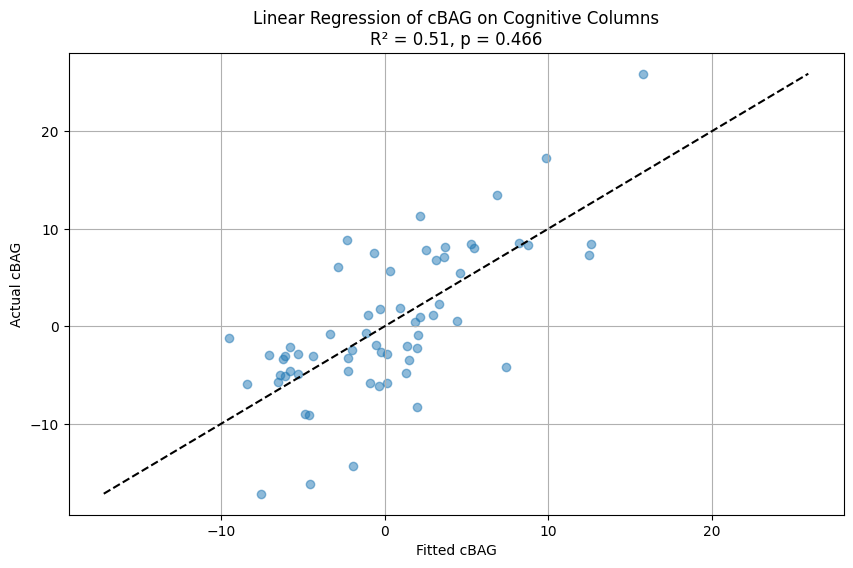

In [21]:
# BAG as a function of cognitive columns using linear regression
# BAG = intercept + parameter1 * cognitive1 + parameter2 * cognitive2 + ... + parameterN * cognitiveN
from scipy.stats import linregress
from statsmodels.stats.multitest import multipletests

cBAG = merged_df['bag_corr']
cognitive_columns = merged_df.columns[cognitive_start:cognitive_end]

# Convert all cognitive columns to numeric, coercing errors to NaN
for col in cognitive_columns:
    merged_df[col] = pd.to_numeric(merged_df[col], errors='coerce')

# Prepare the design matrix for regression
X = merged_df[cognitive_columns]
# Drop rows with NaN in either X or cBAG
mask = X.notna().all(axis=1) & cBAG.notna()
X = X[mask]
cBAG = cBAG[mask]
# Fit the linear regression model
from sklearn.linear_model import LinearRegression
model = LinearRegression().fit(X, cBAG)
# Extract p-values and coefficients
coefficients = model.coef_
intercept = model.intercept_
R2 = model.score(X, cBAG)

# Calculate the overall p-value for the model using an F-test
from sklearn.metrics import mean_squared_error
y_pred = model.predict(X)
mse_model = mean_squared_error(cBAG, y_pred)
mse_null = mean_squared_error(cBAG, [cBAG.mean()] * len(cBAG))
f_statistic = ((mse_null - mse_model) / len(cognitive_columns)) / (mse_model / (len(cBAG) - len(cognitive_columns) - 1))
from scipy.stats import f
pvalue = 1 - f.cdf(f_statistic, len(cognitive_columns), len(cBAG) - len(cognitive_columns) - 1)

# Plot the fitted values vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(model.predict(X), cBAG, alpha=0.5)
plt.plot([cBAG.min(), cBAG.max()], [cBAG.min(), cBAG.max()], 'k--')
plt.xlabel('Fitted cBAG')
plt.ylabel('Actual cBAG')
plt.title(f'Linear Regression of cBAG on Cognitive Columns\nR² = {R2:.2f}, p = {pvalue:.3f}')
plt.grid()
plt.savefig(f'{save_dir}/cBAG_linear_regression_cognitive_columns.png')
plt.show()


### Apply PCA to cognitive columns

In [22]:
# Apply PCA to the cognitive columns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
cognitive_data = merged_df[cognitive_columns].dropna()
# Standardize the data
scaler = StandardScaler()
cognitive_data_scaled = scaler.fit_transform(cognitive_data)
pca = PCA(n_components=5)  # Keep the top 5 principal components
cognitive_pca = pca.fit_transform(cognitive_data_scaled)
# Create a new dataframe for the PCA components
pca_columns = [f'PC{i+1}' for i in range(cognitive_pca.shape[1])]
pca_df = pd.DataFrame(cognitive_pca, columns=pca_columns, index=cognitive_data.index)
print("Explained variance ratio of the top 5 PCs:", pca.explained_variance_ratio_)


Explained variance ratio of the top 5 PCs: [0.25585355 0.13265638 0.10581124 0.07891436 0.06036143]


### cBAG vs. PC from Cognitive Scores

C:\Users\22679\AppData\Local\Temp\ipykernel_29312\3166571840.py:13: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X = X[mask]


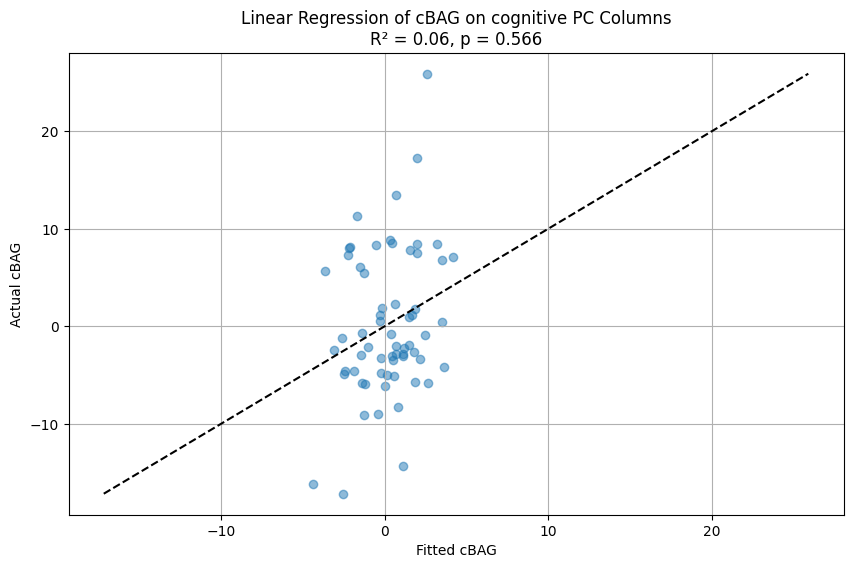

In [23]:
# cBAG as a function of PCs from cognitive columns using linear regression
# BAG = intercept + parameter1 * cognitive1 + parameter2 * cognitive2 + ... + parameterN * cognitiveN
from scipy.stats import linregress
from statsmodels.stats.multitest import multipletests

cBAG = merged_df['bag_corr']


# Prepare the design matrix for regression
X = pca_df
# Drop rows with NaN in either X or cBAG
mask = X.notna().all(axis=1) & cBAG.notna()
X = X[mask]
cBAG = cBAG[mask]
# Fit the linear regression model
from sklearn.linear_model import LinearRegression
model = LinearRegression().fit(X, cBAG)
# Extract p-values and coefficients
coefficients = model.coef_
intercept = model.intercept_
R2 = model.score(X, cBAG)

# Calculate the overall p-value for the model using an F-test
from sklearn.metrics import mean_squared_error
y_pred = model.predict(X)
mse_model = mean_squared_error(cBAG, y_pred)
mse_null = mean_squared_error(cBAG, [cBAG.mean()] * len(cBAG))
f_statistic = ((mse_null - mse_model) / len(pca_df.columns)) / (mse_model / (len(cBAG) - len(pca_df.columns) - 1))
from scipy.stats import f
pvalue = 1 - f.cdf(f_statistic, len(pca_df.columns), len(cBAG) - len(pca_df.columns) - 1)

# Plot the fitted values vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(model.predict(X), cBAG, alpha=0.5)
plt.plot([cBAG.min(), cBAG.max()], [cBAG.min(), cBAG.max()], 'k--')
plt.xlabel('Fitted cBAG')
plt.ylabel('Actual cBAG')
plt.title(f'Linear Regression of cBAG on cognitive PC Columns\nR² = {R2:.2f}, p = {pvalue:.3f}')
plt.grid()
plt.savefig(f'{save_dir}/cBAG_linear_regression_cognitive_PC_columns.png')
plt.show()


## BAG vs. cognitive score

### BAG vs. single cognitive score

In [24]:
# Plot the BAG vs column from 'MOCA_TOTAL' to 'Delayed_paraphrase'
import seaborn as sns

cognitive_start = merged_df.columns.get_loc('MOCA_TOTAL')
cognitive_end = merged_df.columns.get_loc('Delayed_paraphrase') + 1
cognitive_columns = merged_df.columns[cognitive_start:cognitive_end]

# Convert all cognitive columns to numeric, coercing errors to NaN
for col in cognitive_columns:
    merged_df[col] = pd.to_numeric(merged_df[col], errors='coerce')

R2 = []
p_values = []

for column in cognitive_columns:
    # Drop rows with NaN in either column for this analysis
    x = merged_df[column]
    y = merged_df['bag_raw']
    mask = x.notna() & y.notna()
    x = x[mask]
    y = y[mask]
    # Ignore if x or y has identical values (no variance)
    if x.nunique() <= 1 or y.nunique() <= 1:
        R2.append(np.nan)
        p_values.append(np.nan)
        continue
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, alpha=0.5)
    # Add a regression line with R2 and p-value
    sns.regplot(x=x, y=y, scatter=False, color='red', line_kws={'label': 'Regression Line'})
    if len(x) > 1 and len(y) > 1:
        r_squared = np.corrcoef(x, y)[0, 1] ** 2
        from scipy.stats import linregress
        slope, intercept, r_value, p_value, std_err = linregress(x, y)
    else:
        r_squared = np.nan
        p_value = np.nan
    R2.append(r_squared)
    p_values.append(p_value)
    plt.title(f'BAG vs {column}')
    plt.legend(title=f'R² = {r_squared:.2f}, p = {p_value:.3f}')
    plt.ylabel('BAG')
    plt.xlabel(column)
    plt.grid()
    plt.savefig(f'{save_dir}/BAG_vs_{column}.png')
    plt.close()

# Print the top 10 cognitive columns with the highest R2 values
cognitive_r2_df = pd.DataFrame({'cognitive_column': cognitive_columns, 'R2': R2, 'p_value': p_values})
cognitive_r2_df = cognitive_r2_df.sort_values(by='R2', ascending=False)
cognitive_r2_df.to_csv(f'{save_dir}/BAG_vs_cognition_r2_p_values.csv', index=False)
top_10_cognitive = cognitive_r2_df.head(10)
print("Top 10 cognitive columns with highest R² values:")
print(top_10_cognitive)
# Print the top 10 cognitive columns with lowest p-values
top_10_cognitive_p = cognitive_r2_df.sort_values(by='p_value').head(10)
print("\nTop 10 cognitive columns with lowest p-values:")
print(top_10_cognitive_p)


C:\Users\22679\AppData\Local\Temp\ipykernel_29312\888801292.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=f'R² = {r_squared:.2f}, p = {p_value:.3f}')


Top 10 cognitive columns with highest R² values:
            cognitive_column        R2   p_value
21               DigitSymbol  0.075296  0.029530
23            letter_fluency  0.068983  0.037562
26                     ufov3  0.059272  0.054514
12            RAVLT_LEARNING  0.050092  0.077845
25                     ufov2  0.045279  0.094059
15            fwd_max_length  0.045022  0.095020
22                fluency_4x  0.039115  0.120243
27  Story_Immediate_verbatim  0.033491  0.151108
8          Recognized_outof6  0.032064  0.160262
9                AVLT_Trial6  0.026808  0.199762

Top 10 cognitive columns with lowest p-values:
            cognitive_column        R2   p_value
21               DigitSymbol  0.075296  0.029530
23            letter_fluency  0.068983  0.037562
26                     ufov3  0.059272  0.054514
12            RAVLT_LEARNING  0.050092  0.077845
25                     ufov2  0.045279  0.094059
15            fwd_max_length  0.045022  0.095020
22                flu

In [25]:
# Compute FDR correction for p-values
from statsmodels.stats.multitest import multipletests
_, corrected_p_values, _, _ = multipletests(p_values, method='fdr_bh')
# Save the FDR corrected p-value results to a CSV file
cognitive_r2_df['corrected_p_value'] = corrected_p_values
cognitive_r2_df = cognitive_r2_df.sort_values(by='corrected_p_value')
cognitive_r2_df.to_csv(f'{save_dir}/BAG_vs_cognition_r2_FDR_corrected_p_values.csv', index=False)


### BAG vs. z-scored cognitive score composite

In [26]:
# Plot the BAG vs column from 'Memory_Composite' to 'Global_Cognition_Composite'
import seaborn as sns

z_cognitive_start = merged_df.columns.get_loc('Memory_Composite')
z_cognitive_end = merged_df.columns.get_loc('Global_Cognition_Composite') + 1
z_cognitive_columns = merged_df.columns[z_cognitive_start:z_cognitive_end]

R2 = []
p_values = []

for column in z_cognitive_columns:
    # Drop rows with NaN in either column for this analysis
    x = merged_df[column]
    y = merged_df['bag_raw']
    mask = x.notna() & y.notna()
    x = x[mask]
    y = y[mask]
    # Ignore if x or y has identical values (no variance)
    if x.nunique() <= 1 or y.nunique() <= 1:
        R2.append(np.nan)
        p_values.append(np.nan)
        continue
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, alpha=0.5)
    # Add a regression line with R2 and p-value
    sns.regplot(x=x, y=y, scatter=False, color='red', line_kws={'label': 'Regression Line'})
    if len(x) > 1 and len(y) > 1:
        r_squared = np.corrcoef(x, y)[0, 1] ** 2
        from scipy.stats import linregress
        slope, intercept, r_value, p_value, std_err = linregress(x, y)
    else:
        r_squared = np.nan
        p_value = np.nan
    R2.append(r_squared)
    p_values.append(p_value)
    plt.title(f'BAG vs {column}')
    plt.legend(title=f'R² = {r_squared:.2f}, p = {p_value:.3f}')
    plt.ylabel('BAG')
    plt.xlabel(column)
    plt.grid()
    plt.savefig(f'{save_dir}/BAG_vs_{column}.png')
    plt.close()

# Print the top 10 cognitive columns with the highest R2 values
cognitive_r2_df = pd.DataFrame({'z_cognitive_composite_column': z_cognitive_columns, 'R2': R2, 'p_value': p_values})
cognitive_r2_df = cognitive_r2_df.sort_values(by='R2', ascending=False)
# Save the R2 and p-values to a CSV file
cognitive_r2_df.to_csv(f'{save_dir}/BAG_vs_z_cognition_composite_r2_p_values.csv', index=False)
# Print the z-scored cognitive composite columns
print("Top z-scored cognitive composite columns with highest R² values:")
print(cognitive_r2_df.head())
# Print the z-scored cognitive composite columns with lowest p-values
top_cognitive_p = cognitive_r2_df.sort_values(by='p_value').head(10)
print("\nTop z-scored cognitive composite columns with lowest p-values:")
print(top_cognitive_p)


C:\Users\22679\AppData\Local\Temp\ipykernel_29312\3826051028.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=f'R² = {r_squared:.2f}, p = {p_value:.3f}')


Top z-scored cognitive composite columns with highest R² values:
  z_cognitive_composite_column        R2   p_value
2   Processing_Speed_Composite  0.081902  0.022977
3           Language_Composite  0.057324  0.058771
5   Global_Cognition_Composite  0.056126  0.061557
0             Memory_Composite  0.028749  0.184011
4       Visuospatial_Composite  0.005413  0.566592

Top z-scored cognitive composite columns with lowest p-values:
   z_cognitive_composite_column        R2   p_value
2    Processing_Speed_Composite  0.081902  0.022977
3            Language_Composite  0.057324  0.058771
5    Global_Cognition_Composite  0.056126  0.061557
0              Memory_Composite  0.028749  0.184011
4        Visuospatial_Composite  0.005413  0.566592
1  Executive_Function_Composite  0.003877  0.627842


In [27]:
# Plot the BAG vs column from 'Memory_Composite' to 'Global_Cognition_Composite' and sex, age, and APOE4 as covariates
import seaborn as sns

covariate_columns = ['sex_numeric', 'age', 'APOE4']
covariates = merged_df[covariate_columns]

R2 = []
p_values = []

for column in z_cognitive_columns:
    # Drop rows with NaN in either column for this analysis
    x = merged_df[column]
    y = merged_df['bag_raw']
    mask = x.notna() & y.notna() & covariates.notna().all(axis=1)
    x = x[mask]
    y = y[mask]
    covariates_subset = covariates[mask]
    x = x - covariates_subset.dot(np.linalg.lstsq(covariates_subset, x, rcond=None)[0])
    y = y - covariates_subset.dot(np.linalg.lstsq(covariates_subset, y, rcond=None)[0])
    
    # Ignore if x or y has identical values (no variance)
    if x.nunique() <= 1 or y.nunique() <= 1:
        R2.append(np.nan)
        p_values.append(np.nan)
        continue
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, alpha=0.5)
    # Add a regression line with R2 and p-value
    sns.regplot(x=x, y=y, scatter=False, color='red', line_kws={'label': 'Regression Line'})
    if len(x) > 1 and len(y) > 1:
        r_squared = np.corrcoef(x, y)[0, 1] ** 2
        from scipy.stats import linregress
        slope, intercept, r_value, p_value, std_err = linregress(x, y)
    else:
        r_squared = np.nan
        p_value = np.nan
    R2.append(r_squared)
    p_values.append(p_value)
    plt.title(f'BAG vs adjusted {column}')
    plt.legend(title=f'R² = {r_squared:.2f}, p = {p_value:.3f}')
    plt.ylabel('BAG')
    plt.xlabel(column)
    plt.grid()
    plt.savefig(f'{save_dir}/BAG_vs_adjusted_{column}.png')
    plt.close()

# Print the top 10 cognitive columns with the highest R2 values
cognitive_r2_df = pd.DataFrame({'z_cognitive_composite_column': z_cognitive_columns, 'R2': R2, 'p_value': p_values})
cognitive_r2_df = cognitive_r2_df.sort_values(by='R2', ascending=False)
# Save the R2 and p-values to a CSV file
cognitive_r2_df.to_csv(f'{save_dir}/BAG_vs_adjusted_z_cognition_composite_r2_p_values.csv', index=False)
# Print the z-scored cognitive composite columns
print("Top adjusted z-scored cognitive composite columns with highest R² values:")
print(cognitive_r2_df.head())
# Print the z-scored cognitive composite columns with lowest p-values
top_cognitive_p = cognitive_r2_df.sort_values(by='p_value').head(10)
print("\nTop adjusted z-scored cognitive composite columns with lowest p-values:")
print(top_cognitive_p)


C:\Users\22679\AppData\Local\Temp\ipykernel_29312\1253542019.py:40: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=f'R² = {r_squared:.2f}, p = {p_value:.3f}')


Top adjusted z-scored cognitive composite columns with highest R² values:
  z_cognitive_composite_column        R2   p_value
3           Language_Composite  0.060211  0.052577
2   Processing_Speed_Composite  0.056565  0.060522
5   Global_Cognition_Composite  0.042703  0.104173
0             Memory_Composite  0.018029  0.294102
4       Visuospatial_Composite  0.007434  0.501642

Top adjusted z-scored cognitive composite columns with lowest p-values:
   z_cognitive_composite_column        R2   p_value
3            Language_Composite  0.060211  0.052577
2    Processing_Speed_Composite  0.056565  0.060522
5    Global_Cognition_Composite  0.042703  0.104173
0              Memory_Composite  0.018029  0.294102
4        Visuospatial_Composite  0.007434  0.501642
1  Executive_Function_Composite  0.002181  0.716261


### BAG vs. multiple cognitive scores

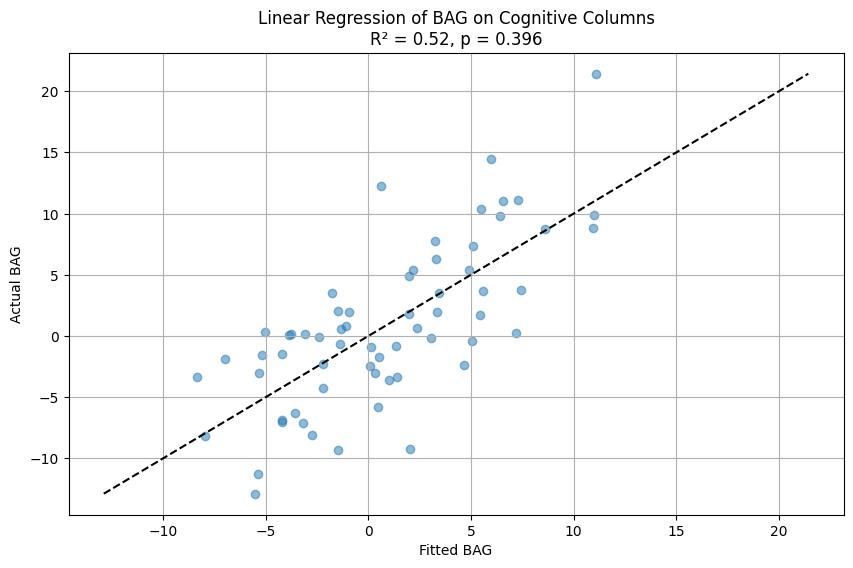

In [28]:
# BAG as a function of cognitive columns using linear regression
# BAG = intercept + parameter1 * cognitive1 + parameter2 * cognitive2 + ... + parameterN * cognitiveN
from scipy.stats import linregress
from statsmodels.stats.multitest import multipletests

BAG = merged_df['bag_raw']
cognitive_columns = merged_df.columns[cognitive_start:cognitive_end]

# Convert all cognitive columns to numeric, coercing errors to NaN
for col in cognitive_columns:
    merged_df[col] = pd.to_numeric(merged_df[col], errors='coerce')

# Prepare the design matrix for regression
X = merged_df[cognitive_columns]
# Drop rows with NaN in either X or BAG
mask = X.notna().all(axis=1) & BAG.notna()
X = X[mask]
BAG = BAG[mask]
# Fit the linear regression model
from sklearn.linear_model import LinearRegression
model = LinearRegression().fit(X, BAG)
# Extract p-values and coefficients
coefficients = model.coef_
intercept = model.intercept_
R2 = model.score(X, BAG)

# Calculate the overall p-value for the model using an F-test
from sklearn.metrics import mean_squared_error
y_pred = model.predict(X)
mse_model = mean_squared_error(BAG, y_pred)
mse_null = mean_squared_error(BAG, [BAG.mean()] * len(BAG))
f_statistic = ((mse_null - mse_model) / len(cognitive_columns)) / (mse_model / (len(BAG) - len(cognitive_columns) - 1))
from scipy.stats import f
pvalue = 1 - f.cdf(f_statistic, len(cognitive_columns), len(BAG) - len(cognitive_columns) - 1)

# Plot the fitted values vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(model.predict(X), BAG, alpha=0.5)
plt.plot([BAG.min(), BAG.max()], [BAG.min(), BAG.max()], 'k--')
plt.xlabel('Fitted BAG')
plt.ylabel('Actual BAG')
plt.title(f'Linear Regression of BAG on Cognitive Columns\nR² = {R2:.2f}, p = {pvalue:.3f}')
plt.grid()
plt.savefig(f'{save_dir}/BAG_linear_regression_cognitive_columns.png')
plt.show()


### BAG vs. PC from cognitive scores

C:\Users\22679\AppData\Local\Temp\ipykernel_29312\921434537.py:13: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X = X[mask]


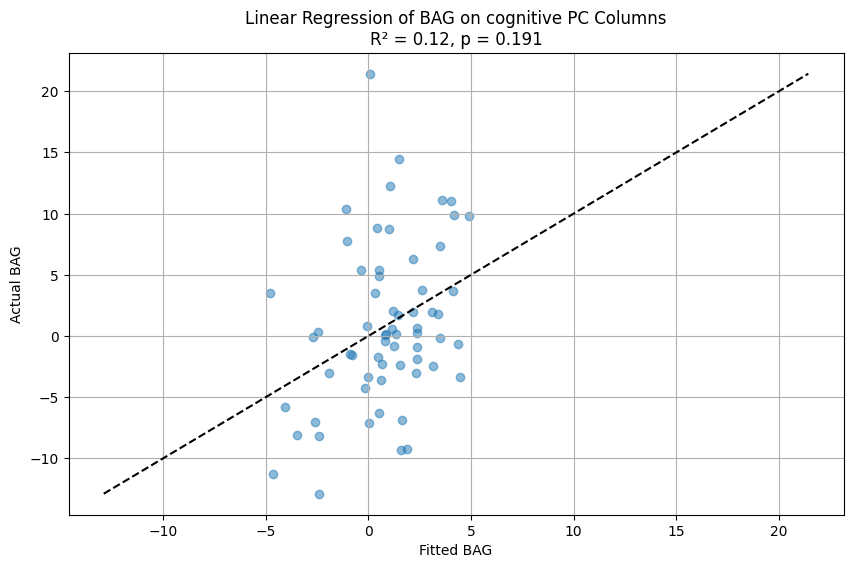

In [29]:
# BAG as a function of PCs from cognitive columns using linear regression
# BAG = intercept + parameter1 * cognitive1 + parameter2 * cognitive2 + ... + parameterN * cognitiveN
from scipy.stats import linregress
from statsmodels.stats.multitest import multipletests

BAG = merged_df['bag_raw']


# Prepare the design matrix for regression
X = pca_df
# Drop rows with NaN in either X or cBAG
mask = X.notna().all(axis=1) & BAG.notna()
X = X[mask]
BAG = BAG[mask]
# Fit the linear regression model
from sklearn.linear_model import LinearRegression
model = LinearRegression().fit(X, BAG)
# Extract p-values and coefficients
coefficients = model.coef_
intercept = model.intercept_
R2 = model.score(X, BAG)

# Calculate the overall p-value for the model using an F-test
from sklearn.metrics import mean_squared_error
y_pred = model.predict(X)
mse_model = mean_squared_error(BAG, y_pred)
mse_null = mean_squared_error(BAG, [BAG.mean()] * len(BAG))
f_statistic = ((mse_null - mse_model) / len(pca_df.columns)) / (mse_model / (len(BAG) - len(pca_df.columns) - 1))
from scipy.stats import f
pvalue = 1 - f.cdf(f_statistic, len(pca_df.columns), len(BAG) - len(pca_df.columns) - 1)

# Plot the fitted values vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(model.predict(X), BAG, alpha=0.5)
plt.plot([BAG.min(), BAG.max()], [BAG.min(), BAG.max()], 'k--')
plt.xlabel('Fitted BAG')
plt.ylabel('Actual BAG')
plt.title(f'Linear Regression of BAG on cognitive PC Columns\nR² = {R2:.2f}, p = {pvalue:.3f}')
plt.grid()
plt.savefig(f'{save_dir}/BAG_linear_regression_cognitive_PC_columns.png')
plt.show()


## Cognitive_Composite vs. cBAG

In [ ]:
# Cognitive_Composite ~ cBAG + Age + Sex + APOE4
# report standardized beta coefficient, p-value and partial R2 for each predictor

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from scipy.stats import f

results = []
for column in z_cognitive_columns:
    # Drop rows with NaN in either column for this analysis
    y = merged_df[column]
    X = merged_df[['bag_corr', 'age', 'sex_numeric', 'APOE4']]
    mask = y.notna() & X.notna().all(axis=1)
    y = y[mask]
    X = X[mask]

    # Fit the full linear regression model
    model = LinearRegression().fit(X, y)
    coefficients = model.coef_
    intercept = model.intercept_
    R2 = model.score(X, y)

    # Standardize coefficients
    X_mean = X.mean()
    X_std = X.std()
    y_mean = y.mean()
    y_std = y.std()

    # Standardize coefficients
    standardized_coefficients = []
    for i, col in enumerate(X.columns):
        if X_std[col] > 0:
            standardized_coefficients.append(coefficients[i] * X_std[col] / y_std)
        else:
            standardized_coefficients.append(0)

    # Fit reduced models for partial R² (fixes feature-name mismatch error)
    reduced_bag = LinearRegression().fit(X.drop(columns=['bag_corr']), y)
    reduced_age = LinearRegression().fit(X.drop(columns=['age']), y)
    reduced_sex = LinearRegression().fit(X.drop(columns=['sex_numeric']), y)
    reduced_APOE4 = LinearRegression().fit(X.drop(columns=['APOE4']), y)

    R2_bag_reduced = reduced_bag.score(X.drop(columns=['bag_corr']), y)
    R2_age_reduced = reduced_age.score(X.drop(columns=['age']), y)
    R2_sex_reduced = reduced_sex.score(X.drop(columns=['sex_numeric']), y)
    R2_APOE4_reduced = reduced_APOE4.score(X.drop(columns=['APOE4']), y)

    # Partial R² for each predictor
    partial_R2_bag = (R2 - R2_bag_reduced) / (1 - R2_bag_reduced) if R2_bag_reduced < 1 else np.nan
    partial_R2_age = (R2 - R2_age_reduced) / (1 - R2_age_reduced) if R2_age_reduced < 1 else np.nan
    partial_R2_sex = (R2 - R2_sex_reduced) / (1 - R2_sex_reduced) if R2_sex_reduced < 1 else np.nan
    partial_R2_APOE4 = (R2 - R2_APOE4_reduced) / (1 - R2_APOE4_reduced) if R2_APOE4_reduced < 1 else np.nan

    # Calculate the overall p-value for the model using an F-test
    y_pred = model.predict(X)
    mse_model = mean_squared_error(y, y_pred)
    mse_null = mean_squared_error(y, [y.mean()] * len(y))
    f_statistic = ((mse_null - mse_model) / X.shape[1]) / (mse_model / (len(y) - X.shape[1] - 1))
    pvalue = 1 - f.cdf(f_statistic, X.shape[1], len(y) - X.shape[1] - 1)

    # Calculate p-value for each predictor via nested-model F-test
    p_values = []
    for i in range(X.shape[1]):
        X_subset = X.drop(columns=X.columns[i])
        model_subset = LinearRegression().fit(X_subset, y)
        y_pred_subset = model_subset.predict(X_subset)
        mse_model_subset = mean_squared_error(y, y_pred_subset)
        f_statistic_subset = ((mse_model_subset - mse_model) / 1) / (mse_model / (len(y) - X.shape[1] - 1))
        p_value_subset = 1 - f.cdf(f_statistic_subset, 1, len(y) - X.shape[1] - 1)
        p_values.append(p_value_subset)

    # Store results for this cognitive composite
    results.append({
        'cognitive_composite': column,
        'R2': R2,
        'p_value': pvalue,
        'bag_corr_coef': coefficients[0],
        'age_coef': coefficients[1],
        'sex_coef': coefficients[2],
        'APOE4_coef': coefficients[3],
        'standardized_bag_corr_coef': standardized_coefficients[0],
        'standardized_age_coef': standardized_coefficients[1],
        'standardized_sex_coef': standardized_coefficients[2],
        'standardized_APOE4_coef': standardized_coefficients[3],
        'partial_R2_bag': partial_R2_bag,
        'partial_R2_age': partial_R2_age,
        'partial_R2_sex': partial_R2_sex,
        'partial_R2_APOE4': partial_R2_APOE4,
        'p_value_bag': p_values[0],
        'p_value_age': p_values[1],
        'p_value_sex': p_values[2],
        'p_value_APOE4': p_values[3]
    })

# Create a dataframe to display results
results_df = pd.DataFrame(results)
results_df.to_csv(f'{save_dir}/cognitive_composite_regression_results.csv', index=False)
print(results_df)



            cognitive_composite        R2   p_value  bag_corr_coef  age_coef  \
0              Memory_Composite  0.361694  0.000025      -0.008022 -0.021045   
1  Executive_Function_Composite  0.035614  0.710187       0.002028 -0.007557   
2    Processing_Speed_Composite  0.364223  0.000023       0.003053 -0.017287   
3            Language_Composite  0.015120  0.924737       0.012155 -0.001224   
4        Visuospatial_Composite  0.302729  0.000281      -0.015651 -0.016092   
5    Global_Cognition_Composite  0.263103  0.001233      -0.001287 -0.012641   

   sex_coef  APOE4_coef  standardized_bag_corr_coef  standardized_age_coef  \
0  0.170680   -0.042489                   -0.108024              -0.568485   
1 -0.170291    0.095517                    0.018625              -0.139255   
2 -0.152194    0.127682                    0.047954              -0.544660   
3 -0.019524    0.043718                    0.110115              -0.022243   
4  0.202983   -0.172498                   -0.2203

In [41]:
# Read the volume data
# ===============================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
from scipy.stats import zscore

# === Load raw regional volume data ===
vol_path = "../../normalized_regional_volumes.csv"
vol_df = pd.read_csv(vol_path)
# fill subject_id to 5 digits with leading zeros
vol_df['subject_id'] = vol_df['subject_id'].apply(lambda x: f"{int(x):05d}")
vol_df.head()

# Prepare a helper to robustly format subject IDs as zero-padded 5-digit strings
def format_id(x):
    try:
        return f"{int(float(x)):05d}"
    except Exception:
        return np.nan

# Ensure subject_id in vol_df is preserved and formatted, and convert only volume columns to numeric
if 'subject_id' in vol_df.columns:
    vol_df['subject_id'] = vol_df['subject_id'].apply(format_id)

# Choose region columns (exclude subject_id)
region_columns = [c for c in vol_df.columns if c != 'subject_id']

# Convert region columns to numeric
for col in region_columns:
    vol_df[col] = pd.to_numeric(vol_df[col], errors='coerce')

R2 = []
p_values = []

# Ensure merged_df subject_id uses the same formatting
merged_df['subject_id'] = merged_df['subject_id'].apply(format_id)

# Merge on the now-consistent string subject_id
merged_vol_df = pd.merge(vol_df, merged_df[['subject_id', 'bag_corr', 'Memory_Composite', 'Executive_Function_Composite',
                                            'Processing_Speed_Composite', 'Language_Composite', 'Visuospatial_Composite',
                                            'Global_Cognition_Composite','age', 'sex_numeric', 'APOE4']], on='subject_id', how='inner')


In [42]:
# Cognitive_Composite ~ left_hippocampal_volume + right_hippocampal_volume + Age + Sex + APOE4
# report standardized beta coefficient, p-value and partial R2 for each predictor

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from scipy.stats import f
results = []

for column in z_cognitive_columns:
    # Drop rows with NaN in either column for this analysis
    y = merged_vol_df[column]
    X = merged_vol_df[['Left-Hippocampus', 'Right-Hippocampus', 'age', 'sex_numeric', 'APOE4']]
    mask = y.notna() & X.notna().all(axis=1)
    y = y[mask]
    X = X[mask]

    # Fit the full linear regression model
    model = LinearRegression().fit(X, y)
    coefficients = model.coef_
    intercept = model.intercept_
    R2 = model.score(X, y)

    # Standardize coefficients
    X_mean = X.mean()
    X_std = X.std()
    y_mean = y.mean()
    y_std = y.std()
    standardized_coefficients = []
    for i, col in enumerate(X.columns):
        if X_std[col] > 0:
            standardized_coefficients.append(coefficients[i] * X_std[col] / y_std)
        else:
            standardized_coefficients.append(0)

    # Fit reduced models for partial R² (fixes feature-name mismatch error)
    reduced_left_hippocampal_volume = LinearRegression().fit(X.drop(columns=['Left-Hippocampus']), y)
    reduced_right_hippocampal_volume = LinearRegression().fit(X.drop(columns=['Right-Hippocampus']), y)
    reduced_age = LinearRegression().fit(X.drop(columns=['age']), y)
    reduced_sex = LinearRegression().fit(X.drop(columns=['sex_numeric']), y)
    reduced_APOE4 = LinearRegression().fit(X.drop(columns=['APOE4']), y)

    R2_left_hippocampal_volume_reduced = reduced_left_hippocampal_volume.score(X.drop(columns=['Left-Hippocampus']), y)
    R2_right_hippocampal_volume_reduced = reduced_right_hippocampal_volume.score(X.drop(columns=['Right-Hippocampus']), y)
    R2_age_reduced = reduced_age.score(X.drop(columns=['age']), y)
    R2_sex_reduced = reduced_sex.score(X.drop(columns=['sex_numeric']), y)
    R2_APOE4_reduced = reduced_APOE4.score(X.drop(columns=['APOE4']), y)

    # Partial R² for each predictor
    partial_R2_left_hippocampal_volume = (R2 - R2_left_hippocampal_volume_reduced) / (1 - R2_left_hippocampal_volume_reduced) if R2_left_hippocampal_volume_reduced < 1 else np.nan
    partial_R2_right_hippocampal_volume = (R2 - R2_right_hippocampal_volume_reduced) / (1 - R2_right_hippocampal_volume_reduced) if R2_right_hippocampal_volume_reduced < 1 else np.nan
    partial_R2_age = (R2 - R2_age_reduced) / (1 - R2_age_reduced) if R2_age_reduced < 1 else np.nan
    partial_R2_sex = (R2 - R2_sex_reduced) / (1 - R2_sex_reduced) if R2_sex_reduced < 1 else np.nan
    partial_R2_APOE4 = (R2 - R2_APOE4_reduced) / (1 - R2_APOE4_reduced) if R2_APOE4_reduced < 1 else np.nan

    # Calculate the overall p-value for the model using an F-test
    y_pred = model.predict(X)
    mse_model = mean_squared_error(y, y_pred)
    mse_null = mean_squared_error(y, [y.mean()] * len(y))
    f_statistic = ((mse_null - mse_model) / X.shape[1]) / (mse_model / (len(y) - X.shape[1] - 1))
    pvalue = 1 - f.cdf(f_statistic, X.shape[1], len(y) - X.shape[1] - 1)

    # Calculate p-value for each predictor via nested-model F-test
    p_values = []
    for i in range(X.shape[1]):
        X_subset = X.drop(columns=X.columns[i])
        model_subset = LinearRegression().fit(X_subset, y)
        y_pred_subset = model_subset.predict(X_subset)
        mse_model_subset = mean_squared_error(y, y_pred_subset)
        f_statistic_subset = ((mse_model_subset - mse_model) / 1) / (mse_model / (len(y) - X.shape[1] - 1))
        p_value_subset = 1 - f.cdf(f_statistic_subset, 1, len(y) - X.shape[1] - 1)
        p_values.append(p_value_subset)

    # Store results for this cognitive composite
    results.append({
        'cognitive_composite': column,
        'R2': R2,
        'p_value': pvalue,
        'left_hippocampal_volume_coef': coefficients[0],
        'right_hippocampal_volume_coef': coefficients[1],
        'age_coef': coefficients[2],
        'sex_coef': coefficients[3],
        'APOE4_coef': coefficients[4],
        'standardized_left_hippocampal_volume_coef': standardized_coefficients[0],
        'standardized_right_hippocampal_volume_coef': standardized_coefficients[1],
        'standardized_age_coef': standardized_coefficients[2],
        'standardized_sex_coef': standardized_coefficients[3],
        'standardized_APOE4_coef': standardized_coefficients[4],
        'partial_R2_left_hippocampal_volume': partial_R2_left_hippocampal_volume,
        'partial_R2_right_hippocampal_volume': partial_R2_right_hippocampal_volume,
        'partial_R2_age': partial_R2_age,
        'partial_R2_sex': partial_R2_sex,
        'partial_R2_APOE4': partial_R2_APOE4,
        'p_value_left_hippocampal_volume': p_values[0],
        'p_value_right_hippocampal_volume': p_values[1],
        'p_value_age': p_values[2],
        'p_value_sex': p_values[3],
        'p_value_APOE4': p_values[4]
    })

# Create a dataframe to display results
results_df = pd.DataFrame(results)
results_df.to_csv(f'{save_dir}/cognitive_composite_regression_results_Hippocampal_Volume.csv', index=False)
print(results_df)



            cognitive_composite        R2   p_value  \
0              Memory_Composite  0.368090  0.000062   
1  Executive_Function_Composite  0.039774  0.795413   
2    Processing_Speed_Composite  0.398822  0.000017   
3            Language_Composite  0.008165  0.992856   
4        Visuospatial_Composite  0.258857  0.003630   
5    Global_Cognition_Composite  0.285252  0.001468   

   left_hippocampal_volume_coef  right_hippocampal_volume_coef  age_coef  \
0                    253.560908                    -311.127960 -0.020420   
1                    125.622110                    -213.278946 -0.007417   
2                     26.935016                    -253.457890 -0.016719   
3                    143.076924                    -221.989793 -0.001738   
4                    -20.681122                     -42.775065 -0.014914   
5                    105.702767                    -208.525931 -0.012242   

   sex_coef  APOE4_coef  standardized_left_hippocampal_volume_coef  \
0  0.188241

## cBAG vs. biological metrics

In [35]:
import seaborn as sns
from scipy.stats import linregress

# Plot cBAG vs biological metrics with regression line, R2, and p-value

biological_start = merged_df.columns.get_loc('Systolic')
biological_end = merged_df.columns.get_loc('BMI') + 1
biological_columns = merged_df.columns[biological_start:biological_end]

R2 = []
p_values = []

for column in biological_columns:
    x = merged_df[column]
    y = merged_df['bag_corr']
    mask = x.notna() & y.notna()
    x = x[mask]
    y = y[mask]
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, alpha=0.5)
    # Add regression line
    sns.regplot(x=x, y=y, scatter=False, color='red', line_kws={'label': 'Regression Line'})
    if len(x) > 1 and len(y) > 1 and x.nunique() > 1 and y.nunique() > 1:
        slope, intercept, r_value, p_value, std_err = linregress(x, y)
        r_squared = r_value ** 2
    else:
        r_squared = float('nan')
        p_value = float('nan')
    R2.append(r_squared)
    p_values.append(p_value)
    plt.title(f'cBAG vs {column}')
    plt.legend(title=f'R² = {r_squared:.2f}, p = {p_value:.3f}')
    plt.ylabel('cBAG')
    plt.xlabel(column)
    plt.grid()
    plt.savefig(f'{save_dir}/cBAG_vs_{column}.png')
    plt.close()

biological_r2_df = pd.DataFrame({'biological_column': biological_columns, 'R2': R2, 'p_value': p_values})
biological_r2_df.to_csv(f'{save_dir}/cBAG_vs_biological_metrics_r2_p_values.csv', index=False)
# Compute FDR correction for p-values
from statsmodels.stats.multitest import multipletests
_, corrected_p_values, _, _ = multipletests(p_values, method='fdr_bh')
# Save the FDR corrected p-value results to a CSV file
# Sort from lowest to highest p-value
biological_r2_df['corrected_p_value'] = corrected_p_values
biological_r2_df = biological_r2_df.sort_values(by='corrected_p_value')
biological_r2_df.to_csv(f'{save_dir}/cBAG_vs_biological_metrics_FDR_corrected_p_values.csv', index=False)

C:\Users\22679\AppData\Local\Temp\ipykernel_18592\2337783272.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=f'R² = {r_squared:.2f}, p = {p_value:.3f}')


## BAG vs. biological metrics

In [36]:
import seaborn as sns
from scipy.stats import linregress

# Plot cBAG vs biological metrics with regression line, R2, and p-value

biological_start = merged_df.columns.get_loc('Systolic')
biological_end = merged_df.columns.get_loc('BMI') + 1
biological_columns = merged_df.columns[biological_start:biological_end]

R2 = []
p_values = []

for column in biological_columns:
    x = merged_df[column]
    y = merged_df['bag_raw']
    mask = x.notna() & y.notna()
    x = x[mask]
    y = y[mask]
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, alpha=0.5)
    # Add regression line
    sns.regplot(x=x, y=y, scatter=False, color='red', line_kws={'label': 'Regression Line'})
    if len(x) > 1 and len(y) > 1 and x.nunique() > 1 and y.nunique() > 1:
        slope, intercept, r_value, p_value, std_err = linregress(x, y)
        r_squared = r_value ** 2
    else:
        r_squared = float('nan')
        p_value = float('nan')
    R2.append(r_squared)
    p_values.append(p_value)
    plt.title(f'BAG vs {column}')
    plt.legend(title=f'R² = {r_squared:.2f}, p = {p_value:.3f}')
    plt.ylabel('BAG')
    plt.xlabel(column)
    plt.grid()
    plt.savefig(f'{save_dir}/BAG_vs_{column}.png')
    plt.close()

biological_r2_df = pd.DataFrame({'biological_column': biological_columns, 'R2': R2, 'p_value': p_values})
biological_r2_df.to_csv(f'{save_dir}/BAG_vs_biological_metrics_r2_p_values.csv', index=False)
# Compute FDR correction for p-values
from statsmodels.stats.multitest import multipletests
_, corrected_p_values, _, _ = multipletests(p_values, method='fdr_bh')
# Save the FDR corrected p-value results to a CSV file
# Sort from lowest to highest p-value
biological_r2_df['corrected_p_value'] = corrected_p_values
biological_r2_df = biological_r2_df.sort_values(by='corrected_p_value')
biological_r2_df.to_csv(f'{save_dir}/BAG_vs_biological_metrics_FDR_corrected_p_values.csv', index=False)

C:\Users\22679\AppData\Local\Temp\ipykernel_18592\1115379745.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=f'R² = {r_squared:.2f}, p = {p_value:.3f}')


## cBAG vs. PCs

In [37]:
# Plot the cBAG vs PC columns
import seaborn as sns

PC_columns = merged_df.columns[merged_df.columns.get_loc('PC1'):merged_df.columns.get_loc('PC30') + 1]

R2 = []
p_values = []

for column in PC_columns:
    # Drop rows with NaN in either column for this analysis
    x = merged_df[column]
    y = merged_df['bag_corr']
    mask = x.notna() & y.notna()
    # Ignore if 'blood_missing' is true
    mask = mask & (merged_df['blood_missing'] != 1)
    x = x[mask]
    y = y[mask]
    # Ignore if x or y has identical values (no variance)
    if x.nunique() <= 1 or y.nunique() <= 1:
        R2.append(np.nan)
        p_values.append(np.nan)
        continue
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, alpha=0.5)
    # Add a regression line with R2 and p-value
    sns.regplot(x=x, y=y, scatter=False, color='red', line_kws={'label': 'Regression Line'})
    if len(x) > 1 and len(y) > 1:
        r_squared = np.corrcoef(x, y)[0, 1] ** 2
        from scipy.stats import linregress
        slope, intercept, r_value, p_value, std_err = linregress(x, y)
    else:
        r_squared = np.nan
        p_value = np.nan
    R2.append(r_squared)
    p_values.append(p_value)
    plt.title(f'cBAG vs {column}')
    plt.legend(title=f'R² = {r_squared:.2f}, p = {p_value:.3f}')
    plt.ylabel('cBAG')
    plt.xlabel(column)
    plt.grid()
    plt.savefig(f'{save_dir}/cBAG_vs_{column}.png')
    plt.close()

# Print the top 10 PC columns with the highest R2 values
PC_r2_df = pd.DataFrame({'PC_column': PC_columns, 'R2': R2, 'p_value': p_values})
PC_r2_df = PC_r2_df.sort_values(by='R2', ascending=False)
# Save the R2 and p-values to a CSV file
PC_r2_df.to_csv(f'{save_dir}/cBAG_vs_PCs_r2_p_values.csv', index=False)
# Print the top 10 PC columns with highest R² values
top_10_PCs = PC_r2_df.head(10)
print("Top 10 PC columns with highest R² values:")
print(top_10_PCs)
# Print the top 10 PC columns with lowest p-values
top_10_PC_p = PC_r2_df.sort_values(by='p_value').head(10)
print("\nTop 10 PC columns with lowest p-values:")
print(top_10_PC_p)

C:\Users\22679\AppData\Local\Temp\ipykernel_18592\2164121165.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=f'R² = {r_squared:.2f}, p = {p_value:.3f}')


Top 10 PC columns with highest R² values:
   PC_column        R2   p_value
28      PC29  0.068844  0.093219
5        PC6  0.059960  0.118070
19      PC20  0.038856  0.210846
17      PC18  0.030551  0.268242
18      PC19  0.027986  0.289631
2        PC3  0.023017  0.337506
26      PC27  0.021656  0.352376
23      PC24  0.016198  0.421869
24      PC25  0.015580  0.430937
29      PC30  0.011096  0.506751

Top 10 PC columns with lowest p-values:
   PC_column        R2   p_value
28      PC29  0.068844  0.093219
5        PC6  0.059960  0.118070
19      PC20  0.038856  0.210846
17      PC18  0.030551  0.268242
18      PC19  0.027986  0.289631
2        PC3  0.023017  0.337506
26      PC27  0.021656  0.352376
23      PC24  0.016198  0.421869
24      PC25  0.015580  0.430937
29      PC30  0.011096  0.506751


## BAG vs. PCs

In [38]:
# Plot the cBAG vs PC columns
import seaborn as sns

PC_columns = merged_df.columns[merged_df.columns.get_loc('PC1'):merged_df.columns.get_loc('PC30') + 1]

R2 = []
p_values = []

for column in PC_columns:
    # Drop rows with NaN in either column for this analysis
    x = merged_df[column]
    y = merged_df['bag_raw']
    mask = x.notna() & y.notna()
    # Ignore if 'blood_missing' is true
    mask = mask & (merged_df['blood_missing'] != 1)
    x = x[mask]
    y = y[mask]
    # Ignore if x or y has identical values (no variance)
    if x.nunique() <= 1 or y.nunique() <= 1:
        R2.append(np.nan)
        p_values.append(np.nan)
        continue
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, alpha=0.5)
    # Add a regression line with R2 and p-value
    sns.regplot(x=x, y=y, scatter=False, color='red', line_kws={'label': 'Regression Line'})
    if len(x) > 1 and len(y) > 1:
        r_squared = np.corrcoef(x, y)[0, 1] ** 2
        from scipy.stats import linregress
        slope, intercept, r_value, p_value, std_err = linregress(x, y)
    else:
        r_squared = np.nan
        p_value = np.nan
    R2.append(r_squared)
    p_values.append(p_value)
    plt.title(f'BAG vs {column}')
    plt.legend(title=f'R² = {r_squared:.2f}, p = {p_value:.3f}')
    plt.ylabel('BAG')
    plt.xlabel(column)
    plt.grid()
    plt.savefig(f'{save_dir}/BAG_vs_{column}.png')
    plt.close()

# Print the top 10 PC columns with the highest R2 values
PC_r2_df = pd.DataFrame({'PC_column': PC_columns, 'R2': R2, 'p_value': p_values})
PC_r2_df = PC_r2_df.sort_values(by='R2', ascending=False)
# Save the R2 and p-values to a CSV file
PC_r2_df.to_csv(f'{save_dir}/BAG_vs_PCs_r2_p_values.csv', index=False)
# Print the top 10 PC columns with highest R² values
top_10_PCs = PC_r2_df.head(10)
print("Top 10 PC columns with highest R² values:")
print(top_10_PCs)
# Print the top 10 PC columns with lowest p-values
top_10_PC_p = PC_r2_df.sort_values(by='p_value').head(10)
print("\nTop 10 PC columns with lowest p-values:")
print(top_10_PC_p)

C:\Users\22679\AppData\Local\Temp\ipykernel_18592\643925440.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=f'R² = {r_squared:.2f}, p = {p_value:.3f}')


Top 10 PC columns with highest R² values:
   PC_column        R2   p_value
2        PC3  0.097075  0.044583
5        PC6  0.074389  0.080544
28      PC29  0.053782  0.139454
25      PC26  0.033298  0.247421
1        PC2  0.030958  0.265024
18      PC19  0.021398  0.355282
17      PC18  0.019150  0.382133
19      PC20  0.018805  0.386492
14      PC15  0.015798  0.427695
26      PC27  0.014653  0.445082

Top 10 PC columns with lowest p-values:
   PC_column        R2   p_value
2        PC3  0.097075  0.044583
5        PC6  0.074389  0.080544
28      PC29  0.053782  0.139454
25      PC26  0.033298  0.247421
1        PC2  0.030958  0.265024
18      PC19  0.021398  0.355282
17      PC18  0.019150  0.382133
19      PC20  0.018805  0.386492
14      PC15  0.015798  0.427695
26      PC27  0.014653  0.445082


## Volume analysis for cBAG

In [39]:
# Read the volume data
# BAG vs. Hippocampal Volume (Relative, z-scored)
# ===============================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
from scipy.stats import zscore

# === Load raw regional volume data ===
vol_path = "../../normalized_regional_volumes.csv"
vol_df = pd.read_csv(vol_path)
# fill subject_id to 5 digits with leading zeros
vol_df['subject_id'] = vol_df['subject_id'].apply(lambda x: f"{int(x):05d}")
vol_df.head()

,subject_id,Left-Cerebellum-Cortex,Left-Thalamus-Proper,Left-Caudate,Left-Putamen,Left-Pallidum,Left-Hippocampus,Left-Amygdala,Left-Accumbens-area,Right-Cerebellum-Cortex,...,ctx-rh-rostralanteriorcingulate,ctx-rh-rostralmiddlefrontal,ctx-rh-superiorfrontal,ctx-rh-superiorparietal,ctx-rh-superiortemporal,ctx-rh-supramarginal,ctx-rh-frontalpole,ctx-rh-temporalpole,ctx-rh-transversetemporal,ctx-rh-insula
0,01912,0.034556,0.003690,0.002369,0.002884,0.000592,0.003499,0.001411,0.000316,0.036822,...,0.002127,0.012920,0.017552,0.007217,0.009087,0.008331,0.000601,0.001328,0.001008,0.006420
1,02110,0.033127,0.003674,0.002186,0.002398,0.000584,0.003233,0.001346,0.000278,0.034020,...,0.001679,0.013291,0.014513,0.008962,0.008608,0.008239,0.000862,0.001503,0.000760,0.004964
2,02224,0.038747,0.003222,0.001971,0.002499,0.000635,0.003526,0.001373,0.000232,0.038528,...,0.002370,0.010306,0.016758,0.008485,0.009313,0.009782,0.000671,0.001659,0.000734,0.005548
3,02227,0.029374,0.003562,0.001977,0.002867,0.000650,0.003325,0.001410,0.000268,0.033789,...,0.002650,0.010865,0.017221,0.007455,0.008871,0.007140,0.000613,0.001738,0.000740,0.005732
4,02373,0.026347,0.003688,0.003211,0.002315,0.000539,0.002857,0.001221,0.000301,0.026977,...,0.002648,0.013922,0.022962,0.007451,0.008105,0.009525,0.000841,0.001229,0.000951,0.006371


In [40]:
# Plot the BAG vs. volume for each region with regression line, R2, and p-value
# Prepare a helper to robustly format subject IDs as zero-padded 5-digit strings
def format_id(x):
    try:
        return f"{int(float(x)):05d}"
    except Exception:
        return np.nan

# Ensure subject_id in vol_df is preserved and formatted, and convert only volume columns to numeric
if 'subject_id' in vol_df.columns:
    vol_df['subject_id'] = vol_df['subject_id'].apply(format_id)

# Choose region columns (exclude subject_id)
region_columns = [c for c in vol_df.columns if c != 'subject_id']

# Convert region columns to numeric
for col in region_columns:
    vol_df[col] = pd.to_numeric(vol_df[col], errors='coerce')

R2 = []
p_values = []

# Ensure merged_df subject_id uses the same formatting
merged_df['subject_id'] = merged_df['subject_id'].apply(format_id)

# Merge on the now-consistent string subject_id
merged_vol_df = pd.merge(vol_df, merged_df[['subject_id', 'bag_corr']], on='subject_id', how='inner')

# Set 'subject_id' as index (optional)
merged_vol_df.set_index('subject_id', inplace=True)

for column in region_columns:
    x = merged_vol_df[column]
    y = merged_vol_df['bag_corr']
    mask = x.notna() & y.notna()
    x = x[mask]
    y = y[mask]
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, alpha=0.5)
    # Add regression line
    sns.regplot(x=x, y=y, scatter=False, color='red', line_kws={'label': 'Regression Line'})
    if len(x) > 1 and len(y) > 1 and x.nunique() > 1 and y.nunique() > 1:
        slope, intercept, r_value, p_value, std_err = linregress(x, y)
        r_squared = r_value ** 2
    else:
        r_squared = float('nan')
        p_value = float('nan')
    R2.append(r_squared)
    p_values.append(p_value)
    plt.title(f'cBAG vs {column}')
    plt.legend(title=f'R² = {r_squared:.2f}, p = {p_value:.3f}')
    plt.ylabel('cBAG')
    plt.xlabel(column)
    plt.grid()
    plt.savefig(f'{save_dir}/cBAG_vs_{column}.png')
    plt.close()

# Build the results DataFrame using the same region_columns (lengths match)
volume_r2_df = pd.DataFrame({'volume_column': region_columns, 'R2': R2, 'p_value': p_values})
volume_r2_df = volume_r2_df.sort_values(by='R2', ascending=False)
top_10_volume = volume_r2_df.head(10)
print("Top 10 volume columns with highest R² values:")
print(top_10_volume)
# Print the top 10 volume columns with lowest p-values
top_10_volume_p = volume_r2_df.sort_values(by='p_value').head(10)
print("\nTop 10 volume columns with lowest p-values:")
print(top_10_volume_p)

# Compute FDR correction for p-values robustly (handle NaNs)
from statsmodels.stats.multitest import multipletests
p_arr = np.array(p_values, dtype=float)
mask = np.isfinite(p_arr)
corrected = np.full_like(p_arr, np.nan, dtype=float)
if mask.any():
    corrected_p = multipletests(p_arr[mask], method='fdr_bh')[1]
    corrected[mask] = corrected_p

# Sort by p-value and save
volume_r2_df = volume_r2_df.sort_values(by='p_value').reset_index(drop=True)
volume_r2_df['corrected_p_value'] = corrected
volume_r2_df.to_csv(f'{save_dir}/volume_vs_cBAG_results.csv', index=False)


C:\Users\22679\AppData\Local\Temp\ipykernel_18592\435366885.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=f'R² = {r_squared:.2f}, p = {p_value:.3f}')


Top 10 volume columns with highest R² values:
                 volume_column        R2   p_value
36          ctx-lh-postcentral  0.097390  0.012058
24     ctx-lh-isthmuscingulate  0.075803  0.027671
73            ctx-rh-precuneus  0.051344  0.071782
39            ctx-lh-precuneus  0.043573  0.097862
43     ctx-lh-superiorparietal  0.042385  0.102663
76      ctx-rh-superiorfrontal  0.038698  0.119236
49               ctx-lh-insula  0.038491  0.120248
18  ctx-lh-caudalmiddlefrontal  0.036710  0.129352
56     ctx-rh-inferiorparietal  0.034570  0.141297
68     ctx-rh-parstriangularis  0.031630  0.159731

Top 10 volume columns with lowest p-values:
                 volume_column        R2   p_value
36          ctx-lh-postcentral  0.097390  0.012058
24     ctx-lh-isthmuscingulate  0.075803  0.027671
73            ctx-rh-precuneus  0.051344  0.071782
39            ctx-lh-precuneus  0.043573  0.097862
43     ctx-lh-superiorparietal  0.042385  0.102663
76      ctx-rh-superiorfrontal  0.038698  

## Volume analysis for BAG

In [41]:
# Plot the BAG vs. volume for each region with regression line, R2, and p-value
# Prepare a helper to robustly format subject IDs as zero-padded 5-digit strings
def format_id(x):
    try:
        return f"{int(float(x)):05d}"
    except Exception:
        return np.nan

# Ensure subject_id in vol_df is preserved and formatted, and convert only volume columns to numeric
if 'subject_id' in vol_df.columns:
    vol_df['subject_id'] = vol_df['subject_id'].apply(format_id)

# Choose region columns (exclude subject_id)
region_columns = [c for c in vol_df.columns if c != 'subject_id']

# Convert region columns to numeric
for col in region_columns:
    vol_df[col] = pd.to_numeric(vol_df[col], errors='coerce')

R2 = []
p_values = []

# Ensure merged_df subject_id uses the same formatting
merged_df['subject_id'] = merged_df['subject_id'].apply(format_id)

# Merge on the now-consistent string subject_id
merged_vol_df = pd.merge(vol_df, merged_df[['subject_id', 'bag_raw']], on='subject_id', how='inner')

# Set 'subject_id' as index (optional)
merged_vol_df.set_index('subject_id', inplace=True)

for column in region_columns:
    x = merged_vol_df[column]
    y = merged_vol_df['bag_raw']
    mask = x.notna() & y.notna()
    x = x[mask]
    y = y[mask]
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, alpha=0.5)
    # Add regression line
    sns.regplot(x=x, y=y, scatter=False, color='red', line_kws={'label': 'Regression Line'})
    if len(x) > 1 and len(y) > 1 and x.nunique() > 1 and y.nunique() > 1:
        slope, intercept, r_value, p_value, std_err = linregress(x, y)
        r_squared = r_value ** 2
    else:
        r_squared = float('nan')
        p_value = float('nan')
    R2.append(r_squared)
    p_values.append(p_value)
    plt.title(f'BAG vs {column}')
    plt.legend(title=f'R² = {r_squared:.2f}, p = {p_value:.3f}')
    plt.ylabel('BAG')
    plt.xlabel(column)
    plt.grid()
    plt.savefig(f'{save_dir}/BAG_vs_{column}.png')
    plt.close()

# Build the results DataFrame using the same region_columns (lengths match)
volume_r2_df = pd.DataFrame({'volume_column': region_columns, 'R2': R2, 'p_value': p_values})
volume_r2_df = volume_r2_df.sort_values(by='R2', ascending=False)
top_10_volume = volume_r2_df.head(10)
print("Top 10 volume columns with highest R² values:")
print(top_10_volume)
# Print the top 10 volume columns with lowest p-values
top_10_volume_p = volume_r2_df.sort_values(by='p_value').head(10)
print("\nTop 10 volume columns with lowest p-values:")
print(top_10_volume_p)

# Compute FDR correction for p-values robustly (handle NaNs)
from statsmodels.stats.multitest import multipletests
p_arr = np.array(p_values, dtype=float)
mask = np.isfinite(p_arr)
corrected = np.full_like(p_arr, np.nan, dtype=float)
if mask.any():
    corrected_p = multipletests(p_arr[mask], method='fdr_bh')[1]
    corrected[mask] = corrected_p

# Sort by p-value and save
volume_r2_df = volume_r2_df.sort_values(by='p_value').reset_index(drop=True)
volume_r2_df['corrected_p_value'] = corrected
volume_r2_df.to_csv(f'{save_dir}/volume_vs_BAG_results.csv', index=False)


C:\Users\22679\AppData\Local\Temp\ipykernel_18592\432810978.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=f'R² = {r_squared:.2f}, p = {p_value:.3f}')


Top 10 volume columns with highest R² values:
                 volume_column        R2   p_value
36          ctx-lh-postcentral  0.114930  0.006138
23     ctx-lh-inferiortemporal  0.074356  0.029261
77     ctx-rh-superiorparietal  0.070491  0.033976
9        Right-Thalamus-Proper  0.064239  0.043300
1         Left-Thalamus-Proper  0.062278  0.046736
62  ctx-rh-medialorbitofrontal  0.055111  0.061869
56     ctx-rh-inferiorparietal  0.055072  0.061964
24     ctx-lh-isthmuscingulate  0.054470  0.063449
57     ctx-rh-inferiortemporal  0.053501  0.065919
79        ctx-rh-supramarginal  0.053454  0.066041

Top 10 volume columns with lowest p-values:
                 volume_column        R2   p_value
36          ctx-lh-postcentral  0.114930  0.006138
23     ctx-lh-inferiortemporal  0.074356  0.029261
77     ctx-rh-superiorparietal  0.070491  0.033976
9        Right-Thalamus-Proper  0.064239  0.043300
1         Left-Thalamus-Proper  0.062278  0.046736
62  ctx-rh-medialorbitofrontal  0.055111  